In [1]:
!pip install -q scikit-learn joblib matplotlib

# -------------------------------------------
# 0. Imports & seeds
# -------------------------------------------
import os, json, random, pickle, math
from zipfile import ZipFile
import numpy as np
np.random.seed(0)
random.seed(0)
import tensorflow as tf
tf.random.set_seed(0)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import itertools

In [2]:
if not os.path.exists("kaggle.json"):
    raise FileNotFoundError("Please upload kaggle.json to the Colab environment (Files -> Upload) before running this cell.")
else:
    kaggle_creds = json.load(open("kaggle.json"))
    os.environ['KAGGLE_USERNAME'] = kaggle_creds['username']
    os.environ['KAGGLE_KEY'] = kaggle_creds['key']
    if not os.path.exists("plantvillage-dataset.zip"):
        print("Downloading PlantVillage dataset from Kaggle (this may take a while)...")
        !kaggle datasets download -q -d abdallahalidev/plantvillage-dataset
    with ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
        print("Extracting dataset...")
        zip_ref.extractall()
    print("Dataset ready.")


Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
Extracting dataset...
Dataset ready.


In [3]:
# -------------------------------------------
# 2. Paths & hyperparams
# -------------------------------------------
BASE_DIR = "plantvillage dataset/color"   # folder inside extracted zip
if not os.path.exists(BASE_DIR):
    raise FileNotFoundError(f"Could not find dataset at '{BASE_DIR}'. Check extraction path.")

IMG_SIZE = (224, 224)   # as requested
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 0

ARTIFACT_DIR = "ml_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

In [4]:
# -------------------------------------------
# 3. Generators (train / val)
# -------------------------------------------
datagen = ImageDataGenerator(rescale=1./255, validation_split=VALIDATION_SPLIT)

train_gen = datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='training',
    shuffle=True,
    class_mode='categorical',
    seed=SEED
)

val_gen = datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='validation',
    shuffle=False,
    class_mode='categorical',
    seed=SEED
)

num_classes = train_gen.num_classes
print(f"Train images: {train_gen.samples}, Val images: {val_gen.samples}, Classes: {num_classes}")

# Save class index mapping (index (str) -> classname)
class_indices = train_gen.class_indices  # classname -> index
index_to_class = {str(v): k for k, v in class_indices.items()}
with open(os.path.join(ARTIFACT_DIR, "class_indices.json"), "w") as f:
    json.dump(index_to_class, f)
print("Saved class index mapping to", os.path.join(ARTIFACT_DIR, "class_indices.json"))



Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Train images: 43456, Val images: 10849, Classes: 38
Saved class index mapping to ml_artifacts/class_indices.json


In [5]:
# -------------------------------------------
# 4. MobileNetV2 feature extractor (frozen)
# -------------------------------------------
print("Loading MobileNetV2 (pretrained on ImageNet) as feature extractor...")
feature_extractor = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
feature_extractor.trainable = False

# Save extractor for Streamlit
feature_extractor.save(os.path.join(ARTIFACT_DIR, "mobilenet_feature_extractor.h5"))
print("Saved feature extractor to", os.path.join(ARTIFACT_DIR, "mobilenet_feature_extractor.h5"))

Loading MobileNetV2 (pretrained on ImageNet) as feature extractor...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Saved feature extractor to ml_artifacts/mobilenet_feature_extractor.h5


In [6]:
# -------------------------------------------
# 5. Extract features (train & val)
# -------------------------------------------
import math

def extract_features_from_generator(gen, model):
    steps = math.ceil(gen.samples / gen.batch_size)
    gen.reset()
    features = model.predict(gen, steps=steps, verbose=1)
    labels = gen.classes  # valid only when gen.shuffle == False
    return features, labels

# For training features, create a generator with shuffle=False (deterministic order)
train_gen_no_shuffle = datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='training',
    shuffle=False,
    class_mode='categorical',
    seed=SEED
)

print("Extracting features for training set...")
train_features, train_labels = extract_features_from_generator(train_gen_no_shuffle, feature_extractor)

print("Extracting features for validation set...")
val_features, val_labels = extract_features_from_generator(val_gen, feature_extractor)

print("Shapes -> train_features:", train_features.shape, "val_features:", val_features.shape)



Found 43456 images belonging to 38 classes.
Extracting features for training set...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1684s 1s/step
Extracting features for validation set...
340/340 ━━━━━━━━━━━━━━━━━━━━ 428s 1s/step
Shapes -> train_features: (43456, 1280) val_features: (10849, 1280)


In [7]:
# -------------------------------------------
# 6. Scale features
# -------------------------------------------
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
val_features_scaled = scaler.transform(val_features)

# Save scaler
with open(os.path.join(ARTIFACT_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
print("Saved scaler to", os.path.join(ARTIFACT_DIR, "scaler.pkl"))


Saved scaler to ml_artifacts/scaler.pkl


In [8]:
# -------------------------------------------
# 7. Train Logistic Regression (fast baseline)
# -------------------------------------------
print("\nTraining Logistic Regression...")
logreg = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    max_iter=300,
    C=1.0,
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)
logreg.fit(train_features_scaled, train_labels)
print("Logistic Regression trained.")

val_preds_logreg = logreg.predict(val_features_scaled)
acc_logreg = accuracy_score(val_labels, val_preds_logreg)
print(f"Logistic Regression validation accuracy: {acc_logreg:.4f}")


Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


max_iter reached after 2686 seconds
Logistic Regression trained.
Logistic Regression validation accuracy: 0.9618


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [9]:
# -------------------------------------------
# 8. Train Random Forest (fast & robust)
# -------------------------------------------
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)
rf.fit(train_features_scaled, train_labels)
print("Random Forest trained.")

val_preds_rf = rf.predict(val_features_scaled)
acc_rf = accuracy_score(val_labels, val_preds_rf)
print(f"Random Forest validation accuracy: {acc_rf:.4f}")


Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  4.3min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


Random Forest trained.


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.3s


Random Forest validation accuracy: 0.8720


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.6s finished



=== Logistic Regression Classification Report ===
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.95      0.96       126
                                 Apple___Black_rot       1.00      0.98      0.99       124
                          Apple___Cedar_apple_rust       0.98      0.98      0.98        55
                                   Apple___healthy       0.99      0.98      0.99       329
                               Blueberry___healthy       0.99      0.99      0.99       300
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       210
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.78      0.80      0.79       102
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       238
               Corn_(maize)_

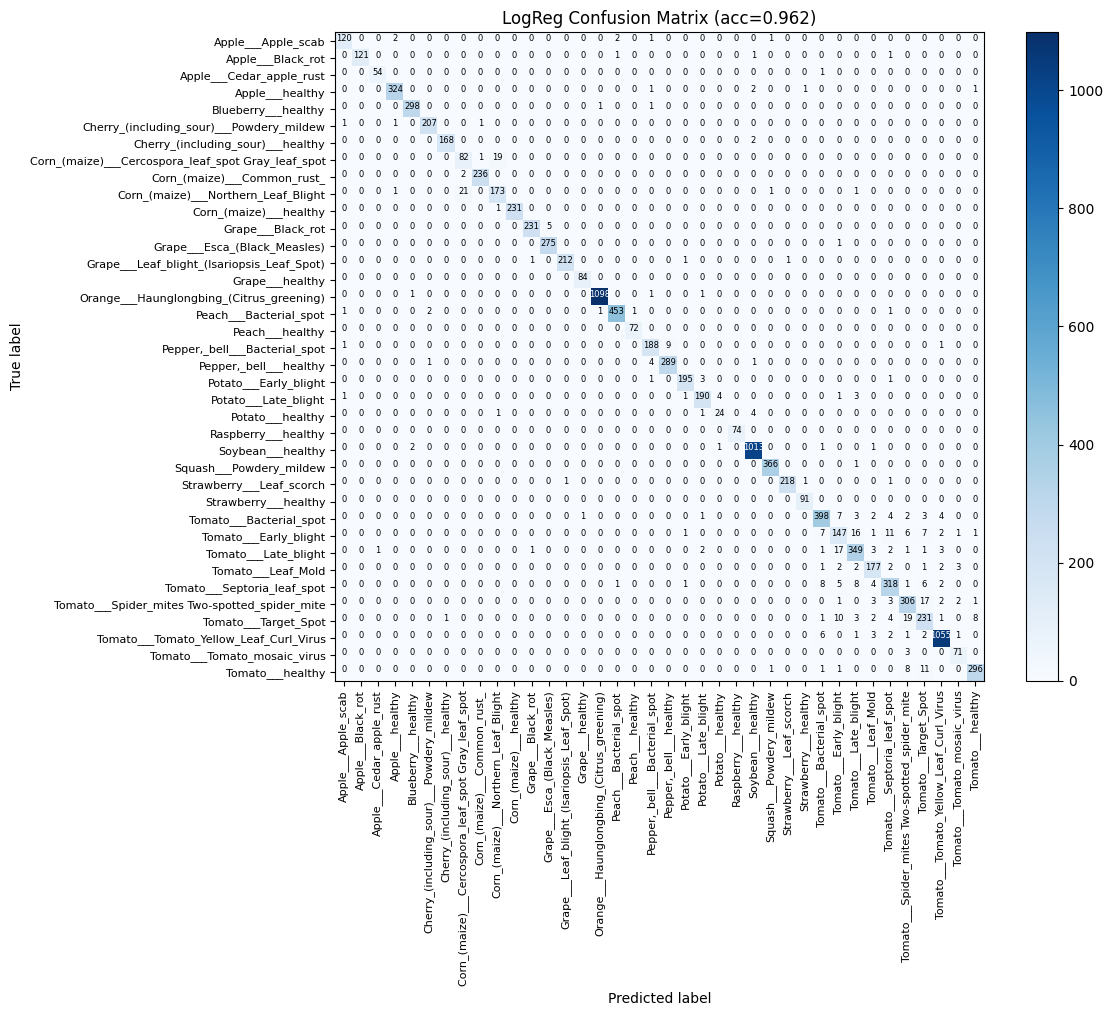


=== Random Forest Classification Report ===
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.86      0.47      0.61       126
                                 Apple___Black_rot       0.95      0.65      0.78       124
                          Apple___Cedar_apple_rust       1.00      0.47      0.64        55
                                   Apple___healthy       0.86      0.91      0.89       329
                               Blueberry___healthy       0.92      0.94      0.93       300
          Cherry_(including_sour)___Powdery_mildew       0.96      0.92      0.94       210
                 Cherry_(including_sour)___healthy       0.95      0.91      0.93       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.86      0.54      0.66       102
                       Corn_(maize)___Common_rust_       0.96      1.00      0.98       238
               Corn_(maize)___Nort

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


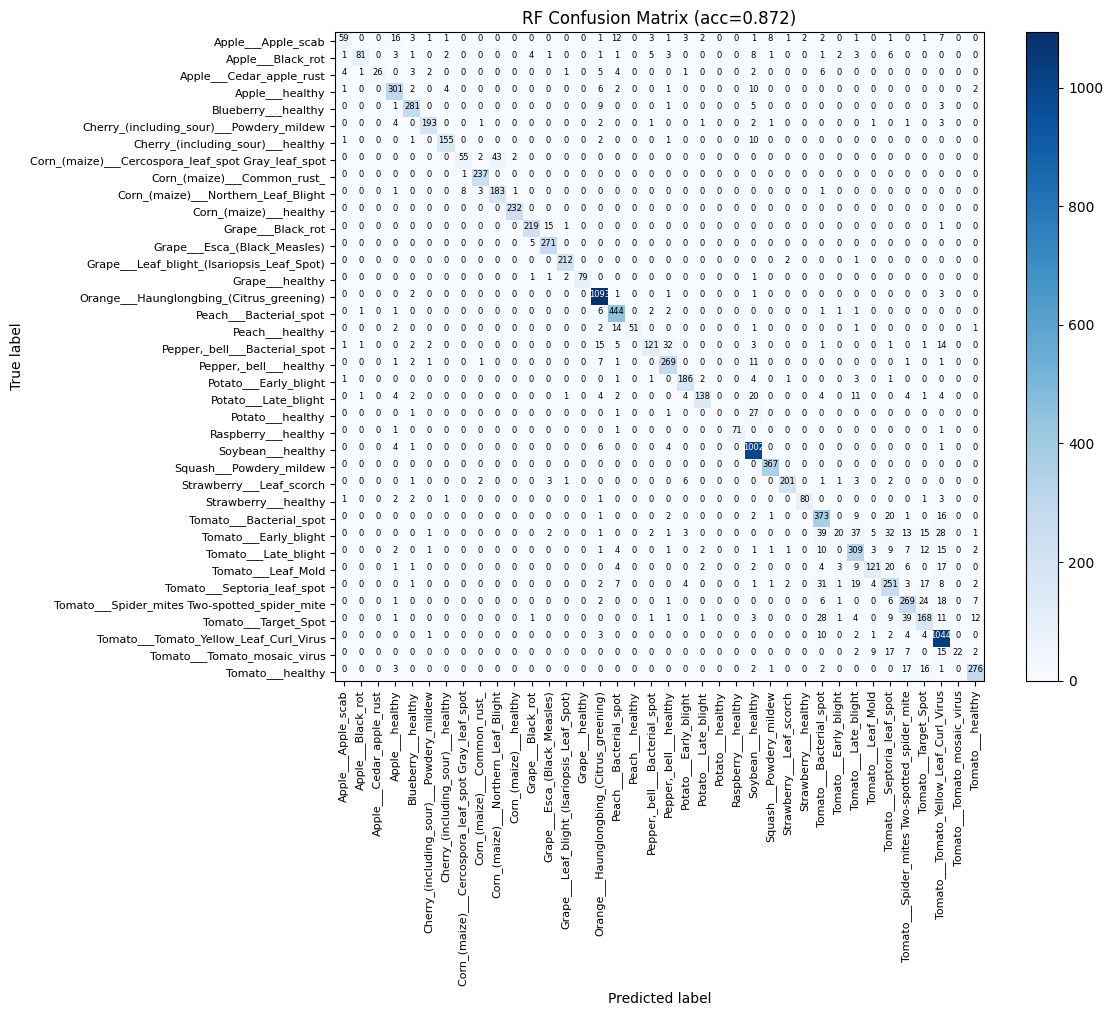

In [10]:
# -------------------------------------------
# 9. Reports & Confusion Matrices
# -------------------------------------------
def plot_confusion_matrix(cm, classes, title='Confusion matrix', normalize=False, outpath=None):
    if normalize:
        cm_plot = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    else:
        cm_plot = cm
    plt.figure(figsize=(12,10))
    plt.imshow(cm_plot, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90, fontsize=8)
    plt.yticks(tick_marks, classes, fontsize=8)
    fmt = '.2f' if normalize else 'd'
    thresh = cm_plot.max() / 2.
    import itertools
    for i, j in itertools.product(range(cm_plot.shape[0]), range(cm_plot.shape[1])):
        plt.text(j, i, format(cm_plot[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm_plot[i, j] > thresh else "black",
                 fontsize=6)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    if outpath:
        plt.savefig(outpath, bbox_inches='tight', dpi=150)
    plt.show()

idx_to_class_list = [index_to_class[str(i)] for i in range(len(index_to_class))]

print("\n=== Logistic Regression Classification Report ===")
print(classification_report(val_labels, val_preds_logreg, target_names=idx_to_class_list))
cm_logreg = confusion_matrix(val_labels, val_preds_logreg)
plot_confusion_matrix(cm_logreg, idx_to_class_list, title=f'LogReg Confusion Matrix (acc={acc_logreg:.3f})', outpath=os.path.join(ARTIFACT_DIR, "confmat_logreg.png"))

print("\n=== Random Forest Classification Report ===")
print(classification_report(val_labels, val_preds_rf, target_names=idx_to_class_list))
cm_rf = confusion_matrix(val_labels, val_preds_rf)
plot_confusion_matrix(cm_rf, idx_to_class_list, title=f'RF Confusion Matrix (acc={acc_rf:.3f})', outpath=os.path.join(ARTIFACT_DIR, "confmat_rf.png"))


In [11]:
# -------------------------------------------
# 10. Save models & metadata
# -------------------------------------------
with open(os.path.join(ARTIFACT_DIR, "logreg_model.pkl"), "wb") as f:
    pickle.dump(logreg, f)
print("Saved Logistic Regression:", os.path.join(ARTIFACT_DIR, "logreg_model.pkl"))

with open(os.path.join(ARTIFACT_DIR, "rf_model.pkl"), "wb") as f:
    pickle.dump(rf, f)
print("Saved Random Forest:", os.path.join(ARTIFACT_DIR, "rf_model.pkl"))

with open(os.path.join(ARTIFACT_DIR, "metadata.json"), "w") as f:
    json.dump({
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "num_classes": num_classes,
        "class_indices": index_to_class
    }, f)
print("Saved metadata:", os.path.join(ARTIFACT_DIR, "metadata.json"))


Saved Logistic Regression: ml_artifacts/logreg_model.pkl
Saved Random Forest: ml_artifacts/rf_model.pkl
Saved metadata: ml_artifacts/metadata.json


In [12]:
# -------------------------------------------
# 11. Zip artifacts for download
# -------------------------------------------
print("\nZipping artifacts...")
!zip -r -q ml_artifacts.zip {ARTIFACT_DIR}
print("Artifacts zipped to ml_artifacts.zip. Download from the left Files pane or use the Colab UI to download.")

print("\nALL DONE. Files in", ARTIFACT_DIR, "->", os.listdir(ARTIFACT_DIR))


Zipping artifacts...
Artifacts zipped to ml_artifacts.zip. Download from the left Files pane or use the Colab UI to download.

ALL DONE. Files in ml_artifacts -> ['confmat_logreg.png', 'confmat_rf.png', 'metadata.json', 'mobilenet_feature_extractor.h5', 'scaler.pkl', 'rf_model.pkl', 'class_indices.json', 'logreg_model.pkl']



Training PCA + Linear SVM...
PCA reduced: (43456, 200)
[LibLinear]SVM trained.
SVM validation accuracy: 0.9417


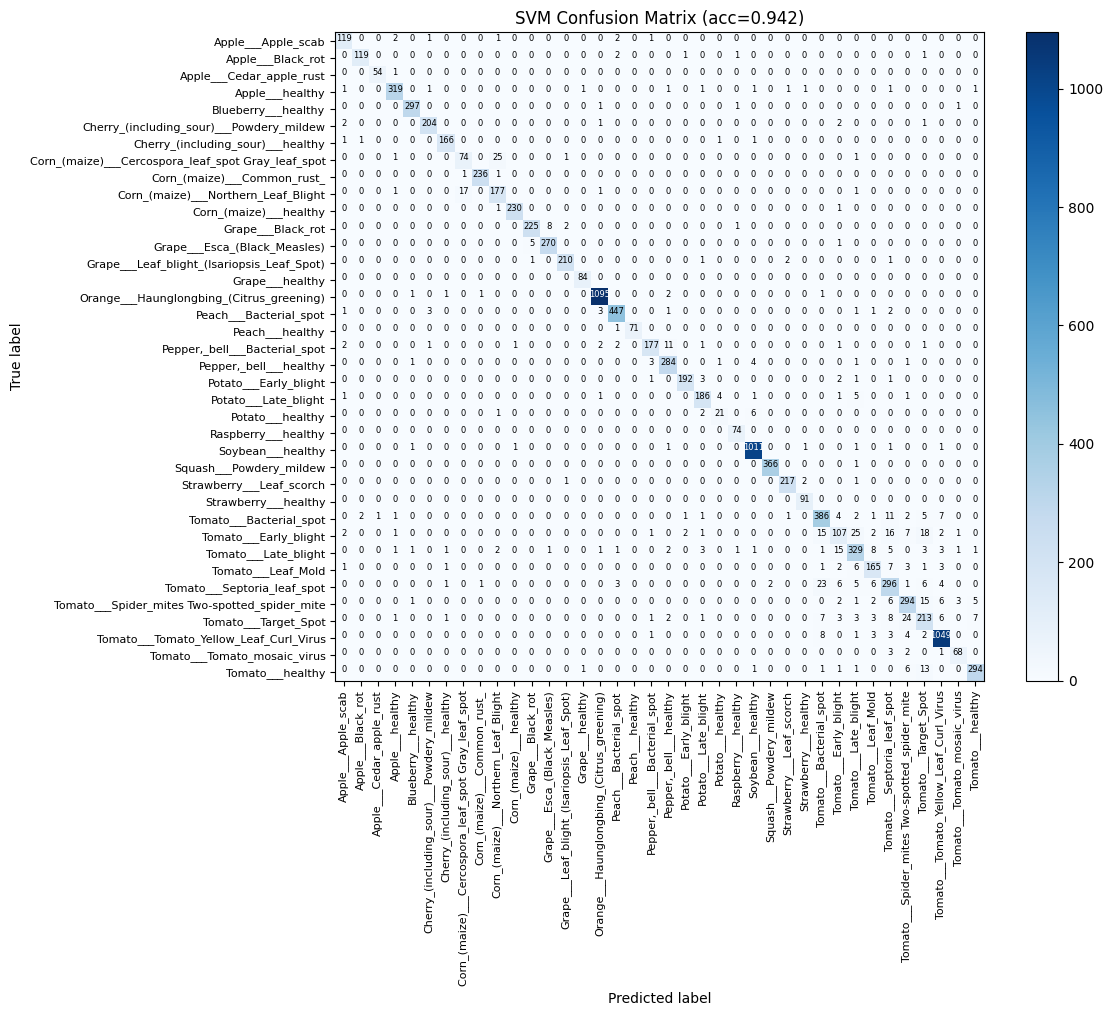


=== SVM Classification Report ===
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.92      0.94      0.93       126
                                 Apple___Black_rot       0.98      0.96      0.97       124
                          Apple___Cedar_apple_rust       0.98      0.98      0.98        55
                                   Apple___healthy       0.97      0.97      0.97       329
                               Blueberry___healthy       0.98      0.99      0.99       300
          Cherry_(including_sour)___Powdery_mildew       0.97      0.97      0.97       210
                 Cherry_(including_sour)___healthy       0.97      0.98      0.97       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.80      0.73      0.76       102
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       238
               Corn_(maize)___Northern_Leaf_

In [14]:
# -------------------------------------------
# 8.5 Train Fast SVM using PCA + LinearSVC
# -------------------------------------------
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC

print("\nTraining PCA + Linear SVM...")

# Reduce features drastically (good range: 100–250 components)
PCA_COMPONENTS = 200

# Fit PCA on training features
pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
train_pca = pca.fit_transform(train_features_scaled)
val_pca = pca.transform(val_features_scaled)

print("PCA reduced:", train_pca.shape)

# Train a fast SVM classifier
svm = LinearSVC(
    C=1.0,
    max_iter=5000,
    verbose=1
)
svm.fit(train_pca, train_labels)
print("SVM trained.")

# Validation accuracy
val_preds_svm = svm.predict(val_pca)
acc_svm = accuracy_score(val_labels, val_preds_svm)
print(f"SVM validation accuracy: {acc_svm:.4f}")

# Confusion matrix for SVM
cm_svm = confusion_matrix(val_labels, val_preds_svm)
plot_confusion_matrix(cm_svm, idx_to_class_list,
                      title=f'SVM Confusion Matrix (acc={acc_svm:.3f})',
                      outpath=os.path.join(ARTIFACT_DIR, "confmat_svm.png"))

print("\n=== SVM Classification Report ===")
print(classification_report(val_labels, val_preds_svm, target_names=idx_to_class_list))

# -------------------------------------------
# Save PCA & SVM
# -------------------------------------------
with open(os.path.join(ARTIFACT_DIR, "pca.pkl"), "wb") as f:
    pickle.dump(pca, f)
print("Saved PCA model to pca.pkl")

with open(os.path.join(ARTIFACT_DIR, "svm_model.pkl"), "wb") as f:
    pickle.dump(svm, f)
print("Saved SVM model to svm_model.pkl")
